# Experiment: APOGEE Korg Synthetic Spectra vs Teff, logg, [M/H], and ExoMol Augmentation

Objective:
- Reuse the local Korg.jl APOGEE synthesis workflow already wired into `jorg.apogee`.
- Visualize how continuum-normalized synthetic spectra respond to `Teff`, `logg`, and `[M/H]`.
- Compare the baseline APOGEE DR17 synthesis against the local `exomol_aug` option that adds `CaH` and `FeH`.
- Keep APOGEE observed-spectrum downloads out of scope for this notebook.


## Notebook Scope

- Parameter sweeps stay on the baseline APOGEE DR17 line list plus the local POKAZATEL water cross section.
- The ExoMol comparison section downloads and prepares the default `CaH` and `FeH` line lists on first use.
- Fixed nuisance labels unless explicitly swept: `[alpha/Fe]=0`, `[C/Fe]=0`, `vmic=1.0 km/s`.
- Use a smaller `mu` grid than the training pipeline for a faster visual notebook run.
- The first baseline run may still take a few minutes because the APOGEE water cross section is generated once on disk.
- The first `exomol_aug` run is slower because Julia has to read the extra molecular line lists.
- Cache every synthetic spectrum under `apogee/output/notebooks/parameter_sweeps/cache/` so reruns are cheap.


In [1]:
from __future__ import annotations

import hashlib
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src").exists():
    for candidate in (REPO_ROOT, *REPO_ROOT.parents):
        if (candidate / "src").exists() and (candidate / ".git").exists():
            REPO_ROOT = candidate
            break

SRC = REPO_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from jorg.apogee.constants import SynthesisGrid, apogee_root, default_korg_root
from jorg.apogee.exomol import default_exomol_assets, ensure_default_exomol_assets
from jorg.apogee.korg import (
    KorgExoMolLineList,
    KorgSynthesisRequest,
    ensure_apogee_water_sigma,
    ensure_korg_environment,
    run_korg_apogee_synthesis,
)

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=4, suppress=True)

REPO_ROOT


PosixPath('/Users/jdli/Project/jorg/jorg')

In [2]:
JULIA_BIN = "julia"
KORG_ROOT = default_korg_root()
APOGEE_ROOT = apogee_root()
OUTPUT_ROOT = APOGEE_ROOT / "output" / "notebooks" / "parameter_sweeps"
CACHE_DIR = OUTPUT_ROOT / "cache"
EXOMOL_ROOT = APOGEE_ROOT / "external" / "exomol"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

BASE_PARAMS = {
    "teff": 3800.0,
    "logg": 4.5,
    "m_h": 0.0,
    "alpha_fe": 0.0,
    "c_fe": 0.0,
    "vmic": 1.0,
}

TEFF_VALUES = [3200.0, 3600.0, 4000.0, 4400.0]
LOGG_VALUES = [0.5, 2.0, 3.5, 5.0]
MH_VALUES = [-1.0, -0.5, 0.0, 0.5]

COMPARE_POINTS = {
    "cool_dwarf": {
        "teff": 3400.0,
        "logg": 5.0,
        "m_h": 0.0,
        "alpha_fe": 0.0,
        "c_fe": 0.0,
        "vmic": 1.0,
    },
    "cool_giant": {
        "teff": 3600.0,
        "logg": 0.5,
        "m_h": 0.0,
        "alpha_fe": 0.0,
        "c_fe": 0.0,
        "vmic": 1.0,
    },
}

MU_VALUES = 6
SYNTHESIS_GRID = SynthesisGrid()
ZOOM_WINDOW = (16140.0, 16220.0)
STRONGEST_WINDOW_HALF_WIDTH = 20.0

settings = {
    "KORG_ROOT": str(KORG_ROOT),
    "OUTPUT_ROOT": str(OUTPUT_ROOT),
    "EXOMOL_ROOT": str(EXOMOL_ROOT),
    "BASE_PARAMS": BASE_PARAMS,
    "TEFF_VALUES": TEFF_VALUES,
    "LOGG_VALUES": LOGG_VALUES,
    "MH_VALUES": MH_VALUES,
    "COMPARE_POINTS": COMPARE_POINTS,
    "MU_VALUES": MU_VALUES,
    "ZOOM_WINDOW": ZOOM_WINDOW,
}
settings


{'KORG_ROOT': '/Users/jdli/Project/jorg/Korg.jl-1.0.1',
 'OUTPUT_ROOT': '/Users/jdli/Project/jorg/jorg/apogee/output/notebooks/parameter_sweeps',
 'EXOMOL_ROOT': '/Users/jdli/Project/jorg/jorg/apogee/external/exomol',
 'BASE_PARAMS': {'teff': 3800.0,
  'logg': 4.5,
  'm_h': 0.0,
  'alpha_fe': 0.0,
  'c_fe': 0.0,
  'vmic': 1.0},
 'TEFF_VALUES': [3200.0, 3600.0, 4000.0, 4400.0],
 'LOGG_VALUES': [0.5, 2.0, 3.5, 5.0],
 'MH_VALUES': [-1.0, -0.5, 0.0, 0.5],
 'COMPARE_POINTS': {'cool_dwarf': {'teff': 3400.0,
   'logg': 5.0,
   'm_h': 0.0,
   'alpha_fe': 0.0,
   'c_fe': 0.0,
   'vmic': 1.0},
  'cool_giant': {'teff': 3600.0,
   'logg': 0.5,
   'm_h': 0.0,
   'alpha_fe': 0.0,
   'c_fe': 0.0,
   'vmic': 1.0}},
 'MU_VALUES': 6,
 'ZOOM_WINDOW': (16140.0, 16220.0)}

In [3]:
def cache_path_for(params: dict[str, float], *, variant: str) -> Path:
    payload = {
        "variant": variant,
        "teff": float(params["teff"]),
        "logg": float(params["logg"]),
        "m_h": float(params["m_h"]),
        "alpha_fe": float(params["alpha_fe"]),
        "c_fe": float(params["c_fe"]),
        "vmic": float(params["vmic"]),
        "mu_values": int(MU_VALUES),
        "resolution": int(SYNTHESIS_GRID.resolution),
    }
    digest = hashlib.sha1(json.dumps(payload, sort_keys=True).encode("utf-8")).hexdigest()[:12]
    return CACHE_DIR / f"{variant}-{digest}.npz"


print("Ensuring local Korg environment and APOGEE water cross section. First run may take a few minutes...")
ensure_korg_environment(KORG_ROOT, julia_bin=JULIA_BIN)
WATER_SIGMA_PATH = ensure_apogee_water_sigma(
    korg_root=KORG_ROOT,
    julia_bin=JULIA_BIN,
    synthesis_grid=SYNTHESIS_GRID,
)
WATER_SIGMA_PATH


Ensuring local Korg environment and APOGEE water cross section. First run may take a few minutes...


PosixPath('/Users/jdli/Project/jorg/jorg/apogee/output/apogee_water_sigma.h5')

In [4]:
EXOMOL_LINELIST: tuple[KorgExoMolLineList, ...] | None = None


def build_exomol_linelist() -> tuple[KorgExoMolLineList, ...]:
    global EXOMOL_LINELIST
    if EXOMOL_LINELIST is not None:
        return EXOMOL_LINELIST

    asset_paths = ensure_default_exomol_assets(EXOMOL_ROOT)
    assets = default_exomol_assets()
    EXOMOL_LINELIST = tuple(
        KorgExoMolLineList(
            species_name=asset.species_name,
            states_path=asset_paths[name][0],
            transitions_path=asset_paths[name][1],
            lower_wavelength=asset.lower_wavelength,
            upper_wavelength=asset.upper_wavelength,
            line_strength_cutoff=asset.line_strength_cutoff,
            temperature_line_strength=asset.temperature_line_strength,
        )
        for name, asset in assets.items()
    )
    return EXOMOL_LINELIST


def synthesize_normalized_spectrum(
    *,
    teff: float,
    logg: float,
    m_h: float,
    alpha_fe: float = 0.0,
    c_fe: float = 0.0,
    vmic: float = 1.0,
    variant: str = "baseline",
    exomol_linelist: tuple[KorgExoMolLineList, ...] | None = None,
) -> dict[str, np.ndarray]:
    if variant not in {"baseline", "exomol_aug"}:
        raise ValueError(f"Unsupported variant: {variant}")

    params = {
        "teff": float(teff),
        "logg": float(logg),
        "m_h": float(m_h),
        "alpha_fe": float(alpha_fe),
        "c_fe": float(c_fe),
        "vmic": float(vmic),
    }
    cache_path = cache_path_for(params, variant=variant)
    if cache_path.exists():
        with np.load(cache_path, allow_pickle=False) as data:
            return {name: data[name] for name in data.files}

    local_exomol_linelist: tuple[KorgExoMolLineList, ...] = ()
    if variant == "exomol_aug":
        local_exomol_linelist = tuple(exomol_linelist or build_exomol_linelist())

    request = KorgSynthesisRequest(
        teff=params["teff"],
        logg=params["logg"],
        m_h=params["m_h"],
        alpha_fe=params["alpha_fe"],
        c_fe=params["c_fe"],
        vmic=params["vmic"],
        water_sigma_path=WATER_SIGMA_PATH,
        exomol_linelist=local_exomol_linelist,
        synthesis_grid=SYNTHESIS_GRID,
        mu_values=MU_VALUES,
        use_exomol_aug=variant == "exomol_aug",
    )
    result = run_korg_apogee_synthesis(request, korg_root=KORG_ROOT, julia_bin=JULIA_BIN)

    normalized_flux = np.divide(
        result.flux,
        result.continuum_flux,
        out=np.full_like(result.flux, np.nan, dtype=np.float32),
        where=np.isfinite(result.continuum_flux) & (result.continuum_flux > 0),
    ).astype(np.float32)

    payload = {
        "wavelength": result.wavelengths.astype(np.float64),
        "flux": result.flux.astype(np.float32),
        "continuum": result.continuum_flux.astype(np.float32),
        "normalized_flux": normalized_flux,
    }
    np.savez_compressed(cache_path, **payload)
    return payload


def run_sweep(
    parameter_name: str,
    values: list[float],
    *,
    variant: str = "baseline",
    exomol_linelist: tuple[KorgExoMolLineList, ...] | None = None,
) -> list[dict[str, object]]:
    outputs: list[dict[str, object]] = []
    for value in values:
        params = dict(BASE_PARAMS)
        params[parameter_name] = float(value)
        spectrum = synthesize_normalized_spectrum(
            **params,
            variant=variant,
            exomol_linelist=exomol_linelist,
        )
        outputs.append(
            {
                "parameter": parameter_name,
                "value": float(value),
                "params": params,
                "variant": variant,
                "spectrum": spectrum,
            }
        )
    return outputs


def format_label(parameter_name: str, value: float) -> str:
    if parameter_name == "teff":
        return f"Teff={value:.0f} K"
    if parameter_name == "logg":
        return f"logg={value:.1f}"
    if parameter_name == "m_h":
        return f"[M/H]={value:+.1f}"
    return f"{parameter_name}={value}"


def format_param_summary(params: dict[str, float]) -> str:
    return (
        f"Teff={params['teff']:.0f} K, "
        f"logg={params['logg']:.1f}, "
        f"[M/H]={params['m_h']:+.1f}"
    )


def plot_sweep(
    results: list[dict[str, object]],
    *,
    parameter_name: str,
    zoom_window: tuple[float, float] = ZOOM_WINDOW,
):
    fig, axes = plt.subplots(1, 2, figsize=(16, 4.8), constrained_layout=True)
    variant = str(results[0].get("variant", "baseline")) if results else "baseline"
    for item in results:
        spectrum = item["spectrum"]
        wavelength = spectrum["wavelength"]
        normalized_flux = spectrum["normalized_flux"]
        label = format_label(parameter_name, float(item["value"]))

        axes[0].plot(wavelength, normalized_flux, lw=1.0, label=label)
        zoom_mask = (wavelength >= zoom_window[0]) & (wavelength <= zoom_window[1])
        axes[1].plot(wavelength[zoom_mask], normalized_flux[zoom_mask], lw=1.2, label=label)

    axes[0].set_title(f"{parameter_name} sweep ({variant}): full APOGEE range")
    axes[1].set_title(f"{parameter_name} sweep ({variant}): zoom {zoom_window[0]:.0f}-{zoom_window[1]:.0f} A")

    for ax in axes:
        ax.set_xlabel("Vacuum wavelength [Angstrom]")
        ax.set_ylabel("Normalized flux")
        ax.set_ylim(0.15, 1.05)

    axes[1].legend(loc="best", fontsize=9)
    return fig, axes


def strongest_difference_window(
    wavelength: np.ndarray,
    delta: np.ndarray,
    *,
    half_width: float = STRONGEST_WINDOW_HALF_WIDTH,
) -> tuple[float, float]:
    finite = np.isfinite(delta)
    if not np.any(finite):
        return ZOOM_WINDOW
    finite_wavelength = wavelength[finite]
    finite_delta = delta[finite]
    max_index = int(np.nanargmax(np.abs(finite_delta)))
    center = float(finite_wavelength[max_index])
    lower = max(float(wavelength[0]), center - half_width)
    upper = min(float(wavelength[-1]), center + half_width)
    return (lower, upper)


def run_variant_comparison(
    params: dict[str, float],
    *,
    exomol_linelist: tuple[KorgExoMolLineList, ...],
) -> dict[str, object]:
    baseline = synthesize_normalized_spectrum(**params, variant="baseline")
    exomol = synthesize_normalized_spectrum(
        **params,
        variant="exomol_aug",
        exomol_linelist=exomol_linelist,
    )
    delta = exomol["normalized_flux"] - baseline["normalized_flux"]
    summary = {
        "max_abs_delta": float(np.nanmax(np.abs(delta))),
        "median_abs_delta": float(np.nanmedian(np.abs(delta))),
        "strongest_window": strongest_difference_window(baseline["wavelength"], delta),
    }
    return {
        "params": params,
        "baseline": baseline,
        "exomol_aug": exomol,
        "delta": delta,
        "summary": summary,
    }


def plot_variant_comparison(
    result: dict[str, object],
    *,
    title: str,
    fixed_zoom: tuple[float, float] = ZOOM_WINDOW,
):
    baseline = result["baseline"]
    exomol = result["exomol_aug"]
    delta = result["delta"]
    wavelength = baseline["wavelength"]
    strongest_window = result["summary"]["strongest_window"]

    fig, axes = plt.subplots(2, 2, figsize=(16, 8), constrained_layout=True)
    fig.suptitle(title, fontsize=14)

    axes[0, 0].plot(wavelength, baseline["normalized_flux"], lw=1.0, label="baseline")
    axes[0, 0].plot(wavelength, exomol["normalized_flux"], lw=1.0, ls="--", label="exomol_aug")
    axes[0, 0].set_title("Full APOGEE range")
    axes[0, 0].set_xlabel("Vacuum wavelength [Angstrom]")
    axes[0, 0].set_ylabel("Normalized flux")
    axes[0, 0].set_ylim(0.15, 1.05)
    axes[0, 0].legend(loc="best", fontsize=9)

    fixed_mask = (wavelength >= fixed_zoom[0]) & (wavelength <= fixed_zoom[1])
    axes[0, 1].plot(wavelength[fixed_mask], baseline["normalized_flux"][fixed_mask], lw=1.2, label="baseline")
    axes[0, 1].plot(wavelength[fixed_mask], exomol["normalized_flux"][fixed_mask], lw=1.2, ls="--", label="exomol_aug")
    axes[0, 1].set_title(f"Fixed zoom {fixed_zoom[0]:.0f}-{fixed_zoom[1]:.0f} A")
    axes[0, 1].set_xlabel("Vacuum wavelength [Angstrom]")
    axes[0, 1].set_ylabel("Normalized flux")
    axes[0, 1].set_ylim(0.15, 1.05)
    axes[0, 1].legend(loc="best", fontsize=9)

    strong_mask = (wavelength >= strongest_window[0]) & (wavelength <= strongest_window[1])
    axes[1, 0].plot(wavelength[strong_mask], baseline["normalized_flux"][strong_mask], lw=1.2, label="baseline")
    axes[1, 0].plot(wavelength[strong_mask], exomol["normalized_flux"][strong_mask], lw=1.2, ls="--", label="exomol_aug")
    axes[1, 0].set_title(
        f"Strongest local window {strongest_window[0]:.0f}-{strongest_window[1]:.0f} A"
    )
    axes[1, 0].set_xlabel("Vacuum wavelength [Angstrom]")
    axes[1, 0].set_ylabel("Normalized flux")
    axes[1, 0].set_ylim(0.15, 1.05)
    axes[1, 0].legend(loc="best", fontsize=9)

    axes[1, 1].plot(wavelength[strong_mask], delta[strong_mask], lw=1.2, color="tab:red")
    axes[1, 1].axhline(0.0, color="black", lw=0.8, alpha=0.6)
    axes[1, 1].set_title("exomol_aug - baseline in strongest local window")
    axes[1, 1].set_xlabel("Vacuum wavelength [Angstrom]")
    axes[1, 1].set_ylabel("Normalized flux difference")

    return fig, axes


In [5]:
teff_sweep = run_sweep("teff", TEFF_VALUES, variant="baseline")
logg_sweep = run_sweep("logg", LOGG_VALUES, variant="baseline")
mh_sweep = run_sweep("m_h", MH_VALUES, variant="baseline")

summary = {
    "n_teff": len(teff_sweep),
    "n_logg": len(logg_sweep),
    "n_m_h": len(mh_sweep),
    "cache_files": len(list(CACHE_DIR.glob("*.npz"))),
}
summary


{'n_teff': 4, 'n_logg': 4, 'n_m_h': 4, 'cache_files': 24}

## Teff Sweep

Expectation:
- Lower `Teff` should strengthen molecular structure and generally deepen the cool-star forest.
- Higher `Teff` should smooth part of the molecular absorption pattern.


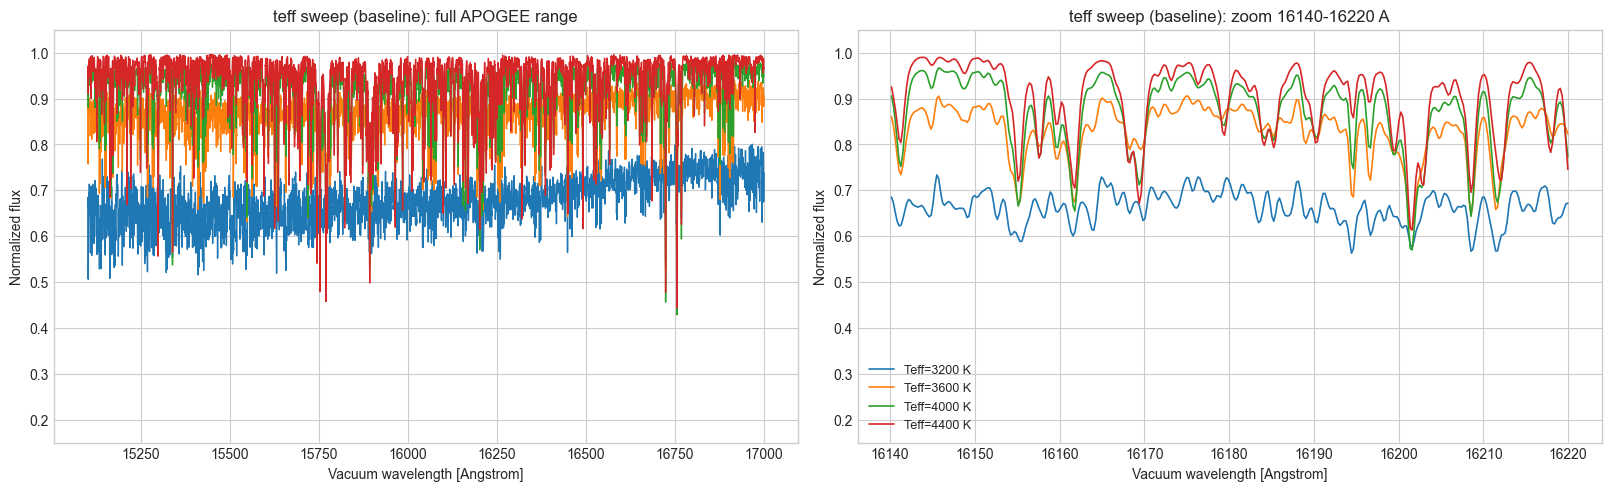

In [6]:
plot_sweep(teff_sweep, parameter_name="teff");


## logg Sweep

Expectation:
- Changing `logg` alters pressure structure, so some line depths and blends should shift even at fixed `Teff` and `[M/H]`.
- The effect is usually subtler than a large `Teff` change, but still visible in selected APOGEE windows.


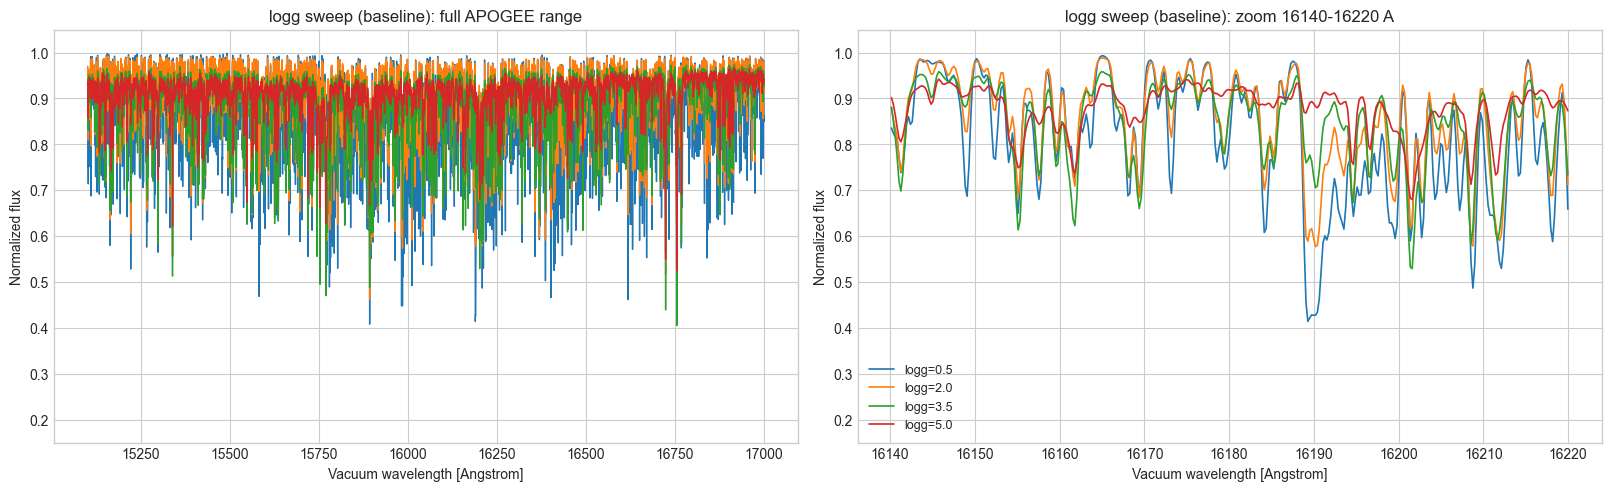

In [7]:
plot_sweep(logg_sweep, parameter_name="logg");


## [M/H] Sweep

Expectation:
- Higher metallicity should increase line blanketing and deepen many atomic and molecular features.
- Lower metallicity should move the spectrum closer to the pseudo-continuum in many regions.


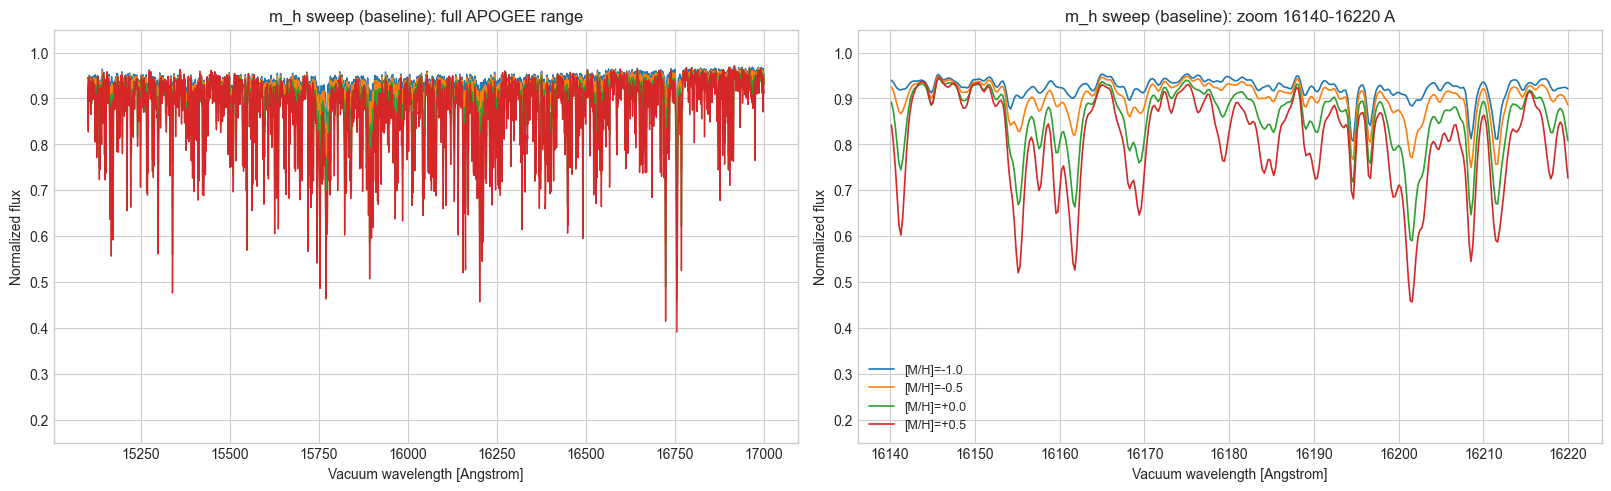

In [8]:
plot_sweep(mh_sweep, parameter_name="m_h");


## ExoMol Comparison

Expectation:
- The extra `CaH` and `FeH` lines should matter most for cooler, high-pressure spectra.
- The difference should stay localized to molecular windows rather than causing a continuum-wide drift.


In [9]:
print("Preparing ExoMol FeH/CaH assets for Korg. First run may take a few minutes...")
EXOMOL_LINELIST = build_exomol_linelist()
[
    {
        "species": line.species_name,
        "states": line.states_path.name,
        "transitions": line.transitions_path.name,
    }
    for line in EXOMOL_LINELIST
]


Preparing ExoMol FeH/CaH assets for Korg. First run may take a few minutes...


[{'species': 'CaH',
  'states': '40Ca-1H__XAB.states',
  'transitions': '40Ca-1H__XAB.trans'},
 {'species': 'FeH',
  'states': '56Fe-1H__MoLLIST.states',
  'transitions': '56Fe-1H__MoLLIST.trans'}]

In [10]:
comparison_results = {
    name: run_variant_comparison(params, exomol_linelist=EXOMOL_LINELIST)
    for name, params in COMPARE_POINTS.items()
}

comparison_summary = []
for name, result in comparison_results.items():
    summary = result["summary"]
    comparison_summary.append(
        {
            "case": name,
            "params": format_param_summary(result["params"]),
            "max_abs_delta": round(summary["max_abs_delta"], 5),
            "median_abs_delta": round(summary["median_abs_delta"], 5),
            "strongest_window_A": tuple(round(value, 1) for value in summary["strongest_window"]),
        }
    )
comparison_summary


[{'case': 'cool_dwarf',
  'params': 'Teff=3400 K, logg=5.0, [M/H]=+0.0',
  'max_abs_delta': 0.0077,
  'median_abs_delta': 0.00011,
  'strongest_window_A': (16245.7, 16285.7)},
 {'case': 'cool_giant',
  'params': 'Teff=3600 K, logg=0.5, [M/H]=+0.0',
  'max_abs_delta': 0.00278,
  'median_abs_delta': 3e-05,
  'strongest_window_A': (16245.7, 16285.7)}]

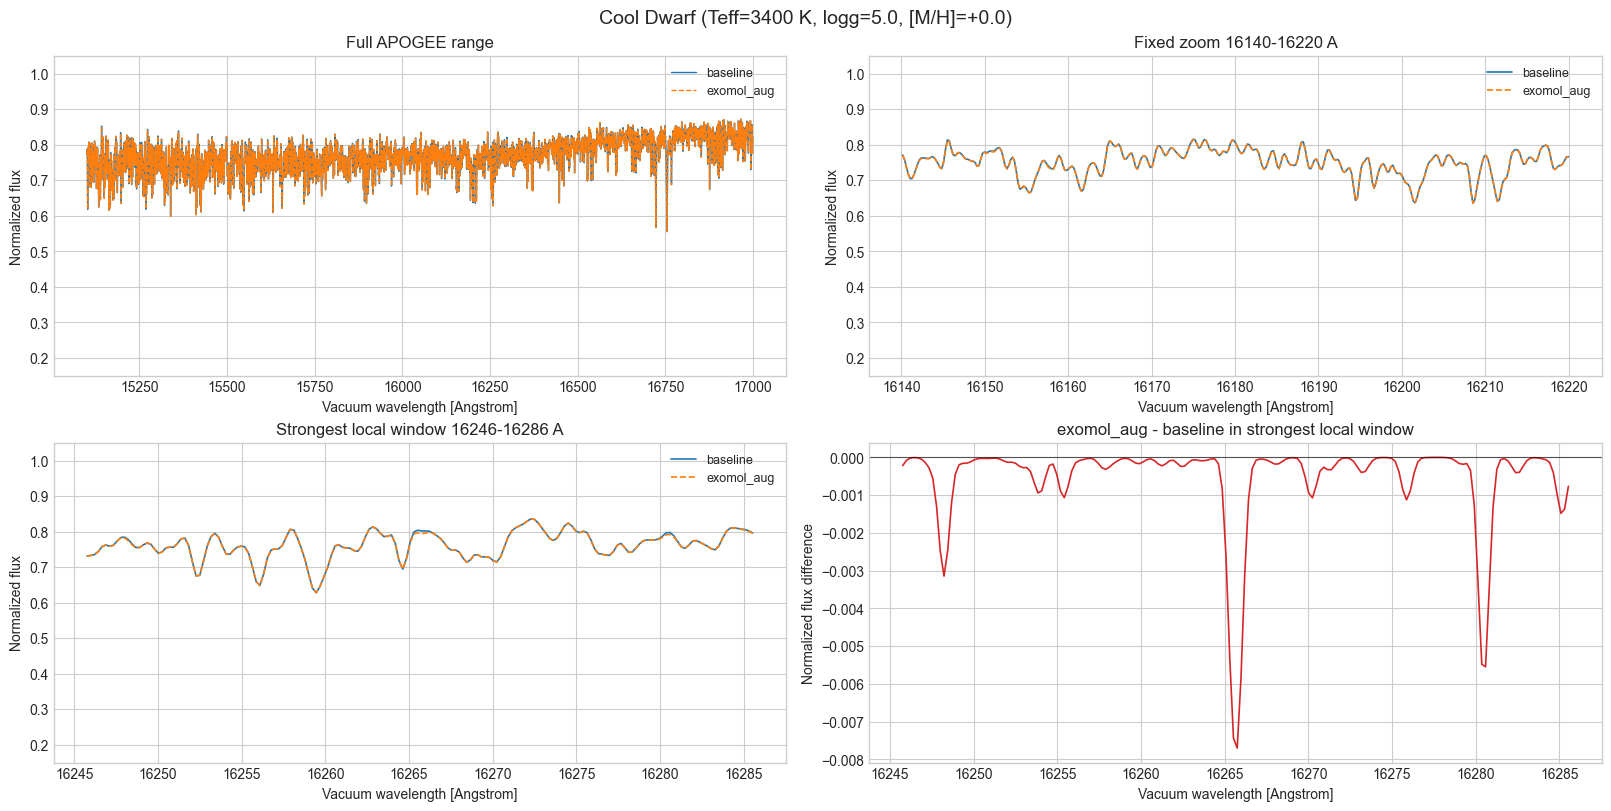

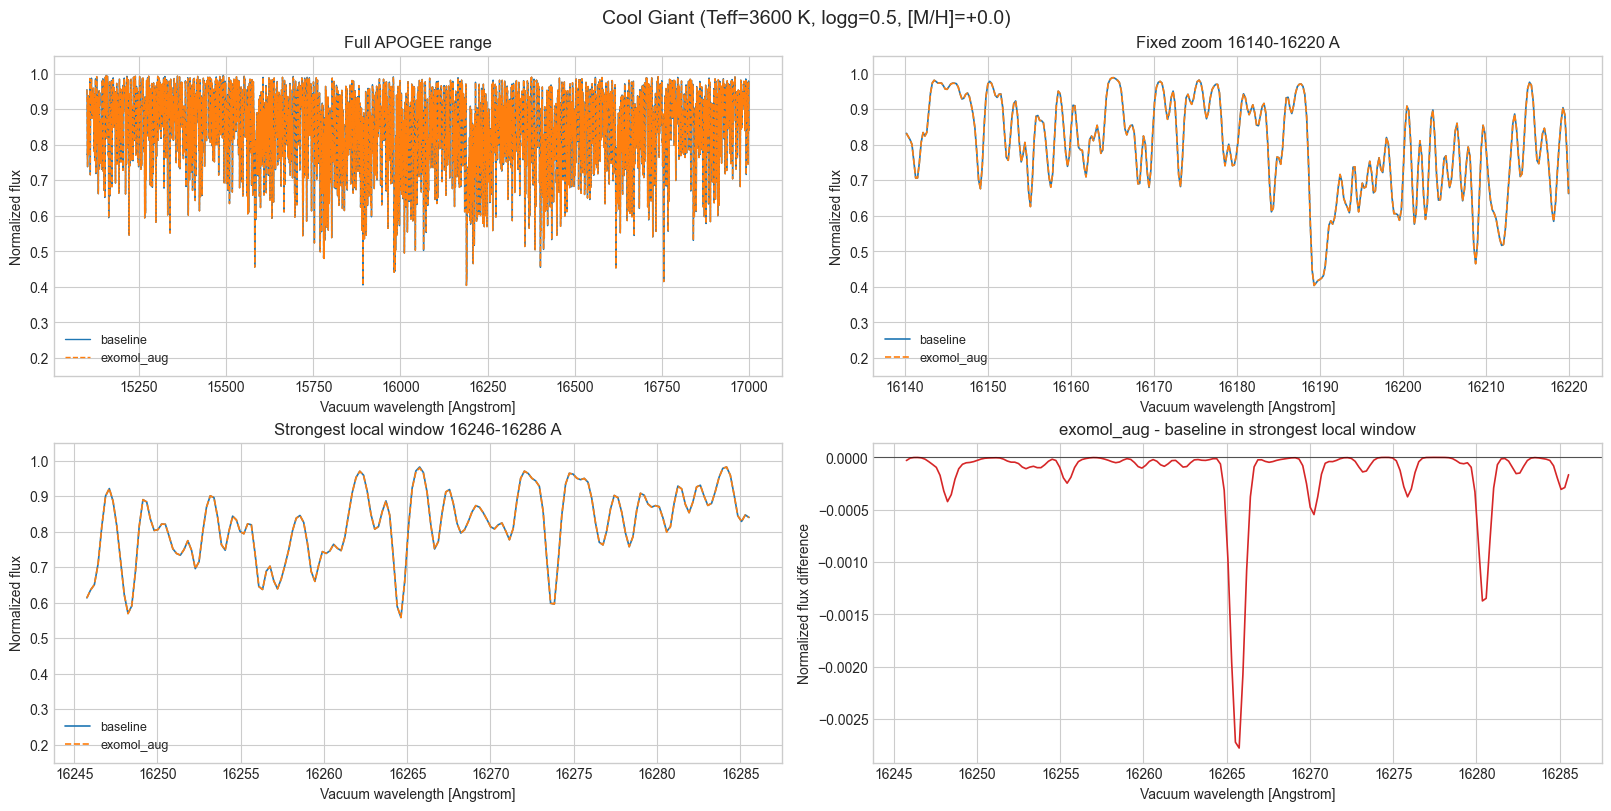

In [11]:
for name, params in COMPARE_POINTS.items():
    title = f"{name.replace('_', ' ').title()} ({format_param_summary(params)})"
    plot_variant_comparison(comparison_results[name], title=title)
    plt.show()


## Next Steps

- Change `BASE_PARAMS`, `TEFF_VALUES`, `LOGG_VALUES`, or `MH_VALUES` and rerun the baseline sweep cell if you want a different parameter scan.
- Add more entries to `COMPARE_POINTS` if you want the `baseline` vs `exomol_aug` comparison at other parts of parameter space.
- If the ExoMol deltas look promising, the next step is to promote this setup into the synthetic-grid builder and benchmark it against APOGEE observations.
